# U2_T2 · Métodos abiertos
### Raíces de ecuaciones no lineales **sin** intervalo inicial

## ¿Qué vas a aprender?

En el tema anterior (métodos cerrados) siempre necesitábamos un intervalo $[a,b]$ con **cambio de signo**. Eso garantiza la convergencia, pero es lento.

Aquí verás seis métodos **abiertos**: solo necesitan uno o dos valores iniciales, así que convergen **mucho más rápido**, aunque **ya no garantizan nada**.

| # | Método | Necesita | Orden de convergencia |
|---|---|---|---|
| 1 | Punto fijo (PF) | un despeje $x=g(x)$ | lineal ($\lvert g'\rvert<1$) |
| 2 | Punto fijo con relajación (PFM) | un despeje + $\lambda$ | lineal, ajustable |
| 3 | Newton-Raphson (NR) | $f$ y $f'$ | **cuadrático** |
| 4 | Newton-Raphson modificado (NRM) | $f,\ f',\ f''$ | cuadrático aun con raíz múltiple |
| 5 | Secante (SEC) | dos puntos, sin derivada | **superlineal** $\approx 1.618$ |
| 6 | Secante modificada (SM) | un punto y un $\delta$ | superlineal |

Además, la **sección 9** extiende punto fijo y Newton a **sistemas 2×2 no lineales** (con Jacobiano y regla de Cramer), que es lo que necesitarás en robótica y control.

---

## ¿Cómo se evalúa?

| Parte | Puntos | Quién califica |
|---|---|---|
| **14 preguntas automáticas** (opción múltiple, iteraciones y programación) | 20 | el cuaderno |
| **6 actividades a mano** (una por método) | 10 cada una | tu profesor |

$$\text{Calificación} = 0.70\,(\text{automático}) + 0.30\,(\text{manual})$$

Se requiere **$\ge 90\%$** de los 20 puntos automáticos para poder enviar.

> **Importante:** la tarea está **sembrada con tu número de control**. Cada compañero tiene ejercicios, coeficientes y casos de prueba distintos. Copiar no sirve.

---

## Cómo usar este cuaderno

1. Escribe tu correo institucional en la celda de identificación.
2. Ve **sección por sección**: lee la teoría y haz la **actividad a mano** (con calculadora) **antes** de ver la solución.
3. Cada método tiene una celda de **práctica** donde programas la función; esa misma función la califica la tarea con **casos ocultos**.
4. Los **laboratorios** (🧪) usan las tablas de tu propio ejercicio para comprobar la teoría: ejecútalos y observa los números.
5. Al final, imprime la **hoja de trabajo manual** y envíala junto con tu cuaderno.

In [1]:
#@title ⚙️ Configuración general — ejecuta esta celda **PRIMERO** (no modificar)
# ============================================================
# CELDA 1 — CONFIGURACIÓN GENERAL
# Detecta si corre en Google Colab o en tu computadora, monta Drive y
# carga el motor de la tarea:
#     Colab    -> grader_ofuscado.txt  (lo que ve el alumno)
#     PC local -> grader_local.py      (el MISMO motor, legible, para depurar)
# Los dos archivos los genera  python tools/build.py  a partir de las
# mismas fuentes: el código es idéntico, solo cambia la presentación.
# ============================================================
import base64
import importlib
import os
import subprocess
import sys
import zlib

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4.5)

# ¿Estamos en Google Colab?
try:
    import google.colab
    ES_COLAB = True
except ImportError:
    ES_COLAB = False

# --- Repositorio de la tarea  <-- EDITAR SOLO SI CAMBIA EL REPO ------
REPO_URL = "https://github.com/ITH-MGL-MN/U2_T2_Metodos_abiertos.git"
REPO_NOMBRE = "U2_T2_Metodos_abiertos"

# --- Solo en tu computadora: qué versión del motor quieres probar ---
#   True  -> grader_local.py     (bundle legible, se puede leer y depurar)
#   False -> grader_ofuscado.txt (exactamente lo que recibe el alumno)
DEBUG_SIN_OFUSCAR = True

if ES_COLAB:
    BASE = "/content/drive/MyDrive/CursoMN"
    REPO = os.path.join(BASE, REPO_NOMBRE)
else:
    # En local: buscar la carpeta de la tarea (la que tiene grader_local.py)
    # subiendo de carpeta en carpeta desde la carpeta actual.
    REPO = os.getcwd()
    for _ in range(4):
        if os.path.exists(os.path.join(REPO, "grader_local.py")):
            break
        _padre = os.path.dirname(REPO)
        if _padre == REPO:
            break
        REPO = _padre
    # Respaldo: ruta local de la tarea en tu Drive (ajústala si la moviste)
    if not os.path.exists(os.path.join(REPO, "grader_local.py")):
        REPO = r"o:\Mi unidad\CursoMN\U2_T2_Metodos_abiertos"

print("Modo          :", "Google Colab" if ES_COLAB else "PC local")
print("Carpeta tarea :", REPO)

# ============================================================
# Montar Drive y traer el repositorio  (solo en Colab)
# En tu computadora no hace nada.
# ============================================================
if ES_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    os.makedirs(BASE, exist_ok=True)
    try:
        if not os.path.exists(REPO):
            subprocess.run(["git", "clone", REPO_URL, REPO], check=True)
        else:
            subprocess.run(["git", "-C", REPO, "pull"], check=True)
        print("✅ Repositorio listo en Drive.")
    except Exception as _exc:
        print("⚠️ No se pudo clonar/actualizar el repositorio:", _exc)
        print("   Si la carpeta ya existe en tu Drive puedes continuar.")
else:
    print("Modo local: no se monta Drive, uso la carpeta de arriba.")

# ============================================================
# Librerías necesarias
# ============================================================
for _pkg in ("sympy", "numpy", "scipy", "matplotlib", "requests", "ipywidgets"):
    try:
        importlib.import_module(_pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", _pkg])

# ============================================================
# Motor de la tarea
# ============================================================
USAR_OFUSCADO = ES_COLAB or (not DEBUG_SIN_OFUSCAR)

if USAR_OFUSCADO:
    _ruta = os.path.join(REPO, "grader_ofuscado.txt")
    with open(_ruta, encoding="utf-8") as f:
        _blob = f.read().strip()
    codigo = zlib.decompress(base64.b64decode(_blob)).decode("utf-8")
else:
    _ruta = os.path.join(REPO, "grader_local.py")
    with open(_ruta, encoding="utf-8") as f:
        codigo = f.read()
    print("🔧 Modo debug local: cargando el bundle legible (sin ofuscar)")

try:
    exec(codigo, globals())
except Exception as _exc:
    raise RuntimeError(
        "No pude cargar el motor desde %s.\n"
        "En Colab: revisa que el repositorio se haya clonado.\n"
        "En local: ejecuta  python tools/build.py  para generarlo.\n"
        "Detalle: %r" % (_ruta, _exc)
    )

print("Motor cargado :", "OFUSCADO (grader_ofuscado.txt)" if USAR_OFUSCADO
      else "BUNDLE local (grader_local.py)")
print("\nListo. Ahora ejecuta la celda de identificación.")

Modo          : PC local
Carpeta tarea : o:\Mi unidad\CursoMN\U2_T2_Metodos_abiertos copy
Modo local: no se monta Drive, uso la carpeta de arriba.
🔧 Modo debug local: cargando el bundle legible (sin ofuscar)
Motor cargado : BUNDLE local (grader_local.py)

Listo. Ahora ejecuta la celda de identificación.


---
## Identifícate

Al ejecutar la celda de configuración, Google te pidió permiso para acceder a tu Drive.
Con esa **misma cuenta** te identifico automáticamente: no tienes que escribir nada.

> # ⚠️ INICIA SESIÓN CON TU CORREO INSTITUCIONAL
> - Debe ser un correo que termine en **@….tecnm.mx** (por ejemplo `@hermosillo.tecnm.mx`).
> - Si inicias con una cuenta personal, verás una alerta y **no podrás continuar**.
> - Es importante para identificarte y validar tu tarea.

Si ya ejecutaste esta celda varias veces, puede seguirte preguntando por otros permisos:
puedes continuar sin seleccionarlos. Solo se necesita el permiso de **leer tu correo**.

In [2]:
#@title 👤 Identificación automática
# ============================================================
# IDENTIFICACIÓN AUTOMÁTICA
# Usa el correo institucional (…@….tecnm.mx) con el que montaste Drive.
# ============================================================
if ES_COLAB:
    import requests
    from google.colab import auth
    import google.auth
    import google.auth.transport.requests

    # Autenticación explícita para asegurar el acceso a la identidad
    try:
        auth.authenticate_user()
        creds, _ = google.auth.default()
        auth_request = google.auth.transport.requests.Request()
        creds.refresh(auth_request)
        info = requests.get(
            "https://www.googleapis.com/drive/v3/about?fields=user",
            headers={"Authorization": "Bearer " + creds.token},
            timeout=20,
        ).json()
        email = info.get("user", {}).get("emailAddress", "")
    except Exception as e:
        print("⚠️ No se pudo obtener tu correo automáticamente.")
        print("Asegúrate de permitir el acceso en la ventana emergente.")
        print("Detalle:", e)
        email = ""
else:
    # Modo local (pruebas): escribe un correo manualmente
    email = "m16330887@hermosillo.tecnm.mx"
    # email = input("Correo institucional (pruebas): ").strip()

# --- Validación del dominio institucional ----------------------------
if email and ("@" in email) and email.lower().endswith(".tecnm.mx"):
    alumno_id = email
    print("✅ Identificado:", email)
    print("   Número de control:", extraer_nc(email))
elif not email:
    alumno_id = None
    print("⛔ No pude identificar tu correo.")
    print("   Vuelve a ejecutar la celda de configuración y acepta el permiso")
    print("   en la ventana de Google.")
else:
    from IPython.display import HTML

    display(HTML(
        '<p style="color:#b00020;background:#ffe0e0;padding:12px;border-radius:8px;'
        'font-weight:bold">⛔ Este correo no es institucional.<br>'
        'Usa tu cuenta @….tecnm.mx. Si iniciaste con otra cuenta, '
        'cierra sesión o usa una ventana de incógnito.</p>'
    ))
    print("Correo detectado:", email)
    alumno_id = None

if alumno_id is None:
    raise RuntimeError(
        "Detente aquí: necesito tu correo institucional para generar tu tarea.\n"
        "Corrige la identificación y vuelve a ejecutar esta celda."
    )

print("\nListo. Continúa con la sección 1.")

✅ Identificado: m16330887@hermosillo.tecnm.mx
   Número de control: 16330887

Listo. Continúa con la sección 1.


---
# 1 · Por qué métodos abiertos

## El precio de la garantía

Bisección y falsa posición solo piden que $f$ sea continua y que $f(a)f(b)<0$. A cambio de esa **garantía** pagan dos precios:

1. **Hay que encontrar el intervalo.** Con la ecuación de Colebrook o con un circuito con diodo eso no es trivial.
2. **Son lentos.** En bisección el intervalo se parte a la mitad en cada paso: si quieres que su ancho final sea menor que una **tolerancia absoluta** $\Delta$ (por ejemplo $\Delta=0.001$), necesitas

$$n \ge \frac{\ln\!\left(\frac{b-a}{\Delta}\right)}{\ln 2}$$

iteraciones. Es una reducción **lineal**: ganar un dígito cuesta $\approx 3.3$ iteraciones.

## Los métodos abiertos cambian la garantía por velocidad

Un método **abierto** parte de una **estimación inicial** $x_0$ y se mueve con la información local de la función (su valor, su pendiente o su curvatura). No pide cambio de signo: por eso puede converger **en 3 o 4 iteraciones**, o puede **divergir sin avisar**.

---

## Los dos números del criterio de paro

Todo método iterativo necesita responder dos preguntas distintas: **¿cuánto avanzó el paso?** y **¿ya me alcanza?** La primera se mide, la segunda se decide.

### 1) Cuánto avanzó: el error relativo aproximado $\varepsilon_a$

Como ya no tenemos un intervalo, medimos **cuánto se movió** la estimación de un paso al siguiente:

$$\boxed{\ \varepsilon_a=\left|\frac{x_{i+1}-x_i}{x_{i+1}}\right|\times 100\,\%\ }$$

| Detalle | Por qué importa |
|---|---|
| En el **denominador** va el valor **nuevo** $x_{i+1}$, no el anterior | es la definición del curso; cambiarlo cambia el número |
| Mide el **movimiento** del paso, **no** la distancia a la raíz | la raíz todavía no la conoces: por eso es solo una **estimación** del error |
| Viene en **porcentaje** | $\varepsilon_a=5\%$ significa que el paso movió la estimación un 5 % |
| En la **iteración 1** se compara contra $x_0$ | es el único valor anterior que existe |
| Cuando $\varepsilon_a$ es pequeño, ¡no siempre estás cerca! | una función muy plana da pasos diminutos sin acercarse a la raíz |

**Ejemplo numérico.** Si $x_1=1.5$ y $x_2=1.416667$, entonces

$$\varepsilon_a=\left|\frac{1.416667-1.5}{1.416667}\right|\times 100=5.8824\,\%$$

### 2) Ya me alcanza: el umbral o tolerancia $\varepsilon_s$

$\varepsilon_s$ es **el número contra el que comparas** $\varepsilon_a$: la precisión con la que te declaras satisfecho.

$$\textbf{Paro cuando}\quad \varepsilon_a \le \varepsilon_s$$

| Pregunta | Respuesta |
|---|---|
| ¿Qué es? | el **valor máximo de $\varepsilon_a$** que estás dispuesto a aceptar |
| ¿De dónde sale? | **se elige**, no se calcula: lo pide el enunciado, el cliente o tu criterio de ingeniería |
| ¿Unidades? | las mismas de $\varepsilon_a$: **por ciento** |
| ¿Si lo pongo muy grande? | paras antes de tener la precisión que necesitas |
| ¿Si lo pongo muy pequeño? | pagas más iteraciones y, de tanto exprimirlo, el redondeo de la máquina puede impedir que se cumpla |

Es exactamente una **tolerancia** de taller: no se deduce del problema, la fija quien manda.

**¿Cuánto vale $\varepsilon_s$ si quiero $n$ dígitos significativos correctos?** Se pide

$$\varepsilon_s = 0.5\times 10^{\,2-n}\ \%$$

| dígitos significativos $n$ | $\varepsilon_s$ que hay que pedir |
|---|---|
| 3 | $0.05\,\%$ |
| 4 | $0.005\,\%$ |
| 5 | $0.0005\,\%$ |
| 6 | $0.00005\,\%$ |

> En esta tarea usaremos valores redondos ($\varepsilon_s=1\%$, $0.1\%$, $0.01\%$, $0.001\%$) y en las **tablas a mano** el valor por omisión es $\varepsilon_s=0.01\%$.

**Siguiendo el ejemplo de arriba**, con $\varepsilon_a=5.8824\%$:

* si $\varepsilon_s=1\%$ → $5.88>1$, **todavía no** has terminado;
* si $\varepsilon_s=10\%$ → $5.88\le 10$, **ya podrías parar**.

> **No confundas:** $\varepsilon_a$ es *lo que mides* en cada paso; $\varepsilon_s$ es *lo que exiges*. Nunca son lo mismo y por eso se comparan.

---

> En cada **actividad a mano** de las secciones siguientes te explico las columnas de su tabla y te pongo un ejemplo guiado con otro problema para que veas el mecanismo completo.

### Veámoslo con el mismo problema

> Un paracaidista de masa $m=68.1$ kg cae desde el reposo. Tras $t=10$ s su velocidad es $v=40$ m/s. Su coeficiente de arrastre $c$ satisface
> $$f(c)=\frac{gm}{c}\left(1-e^{-ct/m}\right)-v=0$$
> con $g=9.81\ \text{m/s}^2$.

Resolvámoslo con un método **cerrado** (bisección en $[5,20]$) y con uno **abierto** (Newton-Raphson desde $c_0=6$), pidiendo el mismo $\varepsilon_s=0.001\%$.

Raiz de referencia: c* = 14.801136 kg/s

BISECCION (cerrado)        NEWTON-RAPHSON (abierto)
 it        c        ea(%)  |  it        c        ea(%)
------------------------------------------------------------
  1   12.50000       nan  |   1   12.15810  50.65019
  2   16.25000  23.07692  |   2   14.53810  16.37079
  3   14.37500  13.04348  |   3   14.79844   1.75920
  4   15.31250   6.12245  |   4   14.80114   0.01823
  5   14.84375   3.15789  |   5   14.80114   0.00000
  6   14.60938   1.60428
  7   14.72656   0.79576
  8   14.78516   0.39630
  9   14.81445   0.19776
 10   14.79980   0.09898
 11   14.80713   0.04946
 12   14.80347   0.02474
 13   14.80164   0.01237
 14   14.80072   0.00619
 15   14.80118   0.00309
 16   14.80095   0.00155
 17   14.80106   0.00077
------------------------------------------------------------
Total: 17 iteraciones          Total: 5 iteraciones


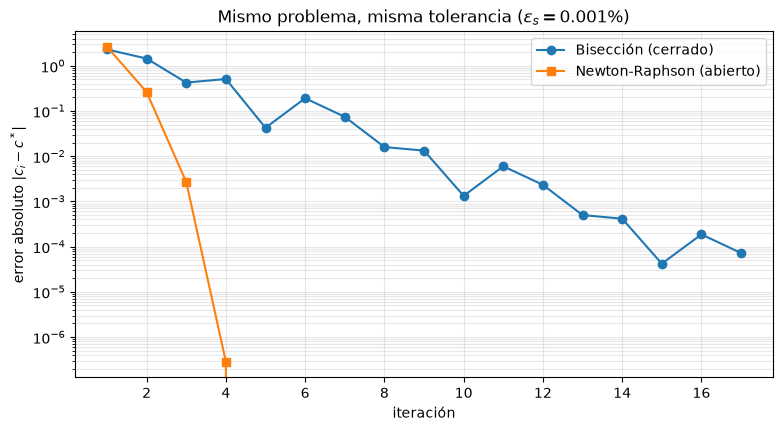

In [3]:
#@title 🔬 Comparación: método cerrado vs método abierto
m, t, v, g = 68.1, 10.0, 40.0, 9.81
ES = 0.001          # criterio de paro, en (%)


def f_par(c):
    return (g * m / c) * (1.0 - np.exp(-c * t / m)) - v


def df_par(c):
    return (g * m / (c * c)) * (np.exp(-c * t / m) * (1.0 + c * t / m) - 1.0)


def biseccion(f, a, b, es=ES, max_iter=100):
    """Metodo CERRADO: parte el intervalo a la mitad."""
    fa = f(a)
    xr, filas = a, []
    for i in range(1, max_iter + 1):
        xr_ant = xr
        xr = 0.5 * (a + b)
        fr = f(xr)
        ea = abs((xr - xr_ant) / xr) * 100.0 if i > 1 else float("nan")
        filas.append((i, xr, ea))
        if fa * fr < 0:
            b = xr
        else:
            a = xr
            fa = fr
        if i > 1 and ea <= es:
            break
    return xr, filas


def newton_demo(f, df, x0, es=ES, max_iter=100):
    """Metodo ABIERTO: usa la tangente."""
    x, filas = x0, []
    for i in range(1, max_iter + 1):
        xn = x - f(x) / df(x)
        ea = abs((xn - x) / xn) * 100.0
        filas.append((i, xn, ea))
        if ea <= es:
            break
        x = xn
    return xn, filas


c_ref, _ = newton_demo(f_par, df_par, 6.0, es=1e-12)
c_bis, fil_bis = biseccion(f_par, 5.0, 20.0)
c_new, fil_new = newton_demo(f_par, df_par, 6.0)

print("Raiz de referencia: c* = %.6f kg/s\n" % c_ref)
print("BISECCION (cerrado)        NEWTON-RAPHSON (abierto)")
print(" it        c        ea(%)  |  it        c        ea(%)")
print("-" * 60)
for k in range(max(len(fil_bis), len(fil_new))):
    izq = " %2d  %9.5f  %8.5f" % fil_bis[k] if k < len(fil_bis) else " " * 21
    der = "  |  %2d  %9.5f  %8.5f" % fil_new[k] if k < len(fil_new) else ""
    print(izq + der)
print("-" * 60)
print("Total: %d iteraciones          Total: %d iteraciones"
      % (len(fil_bis), len(fil_new)))

fig, ax = plt.subplots()
ax.semilogy([f[0] for f in fil_bis], [abs(f[1] - c_ref) for f in fil_bis],
            "o-", label="Bisección (cerrado)")
ax.semilogy([f[0] for f in fil_new], [abs(f[1] - c_ref) for f in fil_new],
            "s-", label="Newton-Raphson (abierto)")
ax.set_xlabel("iteración")
ax.set_ylabel("error absoluto $|c_i-c^*|$")
ax.set_title("Mismo problema, misma tolerancia ($\\varepsilon_s=0.001\\%$)")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

---
# 2 · Fundamentos de los métodos abiertos

## Un solo requisito: una buena estimación inicial

Los métodos abiertos **no** requieren que la raíz esté encerrada. Lo que piden es:

* un **valor inicial** $x_0$ (o dos: $x_0, x_1$ en múltiples raíces o sistemas) razonablemente cerca de la raíz;
* que $f$ sea **derivable** en la zona (para Newton-Raphson y Newton-Raphson Modificado, o al menos continua para las secantes).

**Ventaja:** convergen mucho más rápido y **no hay que encontrar el intervalo**.

**Desventaja:** pueden **divergir** o caer en un ciclo, y no hay forma de saberlo de antemano. La única defensa es probar con otro $x_0$.

## Cómo formula cada método el siguiente punto

| Método | Fórmula | Qué aproxima |
|---|---|---|
| Punto Fijo | $x_{i+1}=g(x_i)$ | despeja $x$ de $f(x)=0$ |
| Punto Fijo Mod. | $x_{i+1}=\lambda g(x_i)+(1-\lambda)x_i$ | amortigua o acelera el despeje |
| Newton-Raphson | $x_{i+1}=x_i-\dfrac{f(x_i)}{f'(x_i)}$ | la tangente |
| Newton-Raphson Mod. | $x_{i+1}=x_i-\dfrac{f(x_i)f'(x_i)}{[f'(x_i)]^2-f(x_i)f''(x_i)}$ | la tangente "corregida" para raíces múltiples |
| Secante | $x_{i+1}=x_i-\dfrac{f(x_i)(x_{i-1}-x_i)}{f(x_{i-1})-f(x_i)}$ | la **secante** que pasa por dos puntos |
| Secante Mod. | $x_{i+1}=x_i-\dfrac{\delta\,x_i\,f(x_i)}{f(x_i+\delta x_i)-f(x_i)}$ | la pendiente con un paso $\delta$ fijo |

## Recordatorio: orden de convergencia

Si $E_i$ es el error en la iteración $i$:

* **lineal:** $E_{i+1}\approx c\,E_i$ — cada iteración gana un **número constante** de dígitos (Punto Fijo, Punto Fijo Mod., bisección).
* **superlineal:** $E_{i+1}\approx c\,E_i^{1.618}$ — la secante.
* **cuadrático:** $E_{i+1}\approx c\,E_i^{2}$ — **se duplican** los dígitos correctos (Newton-Raphson, Newton-Raphson Mod.).

$$E_{t,i+1}\approx-\frac{f''(x_r)}{2f'(x_r)}E_{t,i}^{2}\qquad\text{(Newton-Raphson)}$$

## ¿Cuándo falla un método abierto?

Ninguno de los seis avisa cuando se equivoca. Los modos de falla son tres, y cada uno se estudia en su sección:

1. **Mala estimación inicial** → la iteración se aleja de la raíz y se desborda (secciones 3 y 4).
2. **Quedar atrapado en un ciclo** → oscila entre dos valores y nunca avanza; es típico cuando hay un máximo o un mínimo local en el camino (sección 5).
3. **Dividir entre cero** → el denominador se anula: $f'(x_i)=0$ en Newton-Raphson (secciones 5 y 6), $f(x_i+\delta)=f(x_i)$ en la secante modificada (sección 8) o $\det J=0$ en los sistemas 2×2 (sección 9).

Como no hay garantía, la defensa práctica es siempre la misma: probar **varios** $x_0$, **graficar** $f$ alrededor de la estimación y revisar el **residuo** $|f(x_{\text{final}})|$.

---

### ✏️ Pregunta 1

In [4]:
#@title 🧪 Pregunta 1 · limitación de los métodos cerrados
MI_TAREA = generar_tarea(alumno_id)   # tu tarea queda guardada en MI_TAREA
pregunta(1)

# Tarea · Unidad 2 - Tarea 2: Métodos Abiertos

**Alumno:** `m16330887@hermosillo.tecnm.mx`  ·  **NC:** `16330887`  ·  **Puntos automáticos:** 20

Esta tarea tiene **14** preguntas automáticas (20 puntos) y **6** actividades a mano que revisa tu profesor (30% de la calificación).

#### Pregunta 1: Cuando falla un metodo abierto

**Valor:** $\frac{1}{20}$ puntos

...

a) Siempre converge si la funcion es continua

b) Solo falla si la funcion es un polinomio

c) Nunca requiere criterio de paro

d) Puede fallar por una mala estimacion inicial o por $f'(x)=0$

RadioButtons(layout=Layout(width='170px'), options=(('a)', 0), ('b)', 1), ('c)', 2), ('d)', 3)), value=None)

---
# 3 · Punto fijo (PF)

## La idea

De $f(x)=0$ despejamos una $x$ y la llamamos $g$:

$$x=g(x)\qquad\Longrightarrow\qquad x_{i+1}=g(x_i)$$

**Dos maneras de conseguir el despeje:**

1. **Despeje algebraico directo.** De $x^2-2x-3=0$ podemos sacar $x=\dfrac{x^2-3}{2}$, o $x=\sqrt{2x+3}$, o $x=\dfrac{2x+3}{x}$… ¡todas son válidas algebraicamente!
2. **Sumar $x$ en ambos lados.** De $f(x)=0$ se obtiene $x=x+f(x)$, es decir $g(x)=x+f(x)$.

## ¿Cuál despeje sirve? El criterio $\lvert g'(x)\rvert<1$

Sea $x_r$ la raíz. En cada iteración el error se transforma así (teorema del valor medio):

$$E_{i+1}=g'(\xi)\,E_i,\qquad \xi\ \text{entre}\ x_i\ \text{y}\ x_r$$

$$\boxed{\ \text{El método converge si y solo si}\quad \lvert g'(x_r)\rvert<1\ }$$

| Comportamiento de $g'$ | Qué hace la iteración |
|---|---|
| $0<g'<1$ | **monótona** (se acerca en escalera, lento si $g'\to1$) |
| $-1<g'<0$ | **oscilatoria** (espiral alrededor de la raíz) |
| $g'>1$ | **diverge** (crece sin oscilar) |
| $g'<-1$ | **diverge oscilando** |

Y si quieres saber **cuántas iteraciones** hacen falta para llegar a $\varepsilon_s$ partiendo de un error inicial $E_0$:

$$k\ \ge\ \frac{\ln(\varepsilon_s/E_0)}{\ln\lvert g'(\xi)\rvert}$$

## Ejemplo de la trampa

Para $f(x)=x^2-2x-3=0$ (raíz positiva $x_r=3$):

* con $x=\dfrac{x^2-3}{2}$ tenemos $g'=x$, entonces $g'(3)=3>1$ → **diverge**;
* con $x=\sqrt{2x+3}$ tenemos $g'=\dfrac{1}{\sqrt{2x+3}}$, entonces $g'(3)=\dfrac{1}{3}<1$ → **converge**.

El mismo problema, dos despejes, dos destinos. **Elegir el despeje es parte del método.**

---

## ✏️ Actividad a mano · Punto fijo

Resuelve tu ejercicio de la Celda 1 **con calculadora**, llenando las columnas $g(x_i)$, $x_{i+1}$ y $\varepsilon_a$ de la tabla. Después reporta en la celda 2 la lista `[x_1, x_2, x_3]` y compara.

In [5]:
#@title ✏️ Punto fijo · Celda 1 de 2 — enunciado y tabla para llenar
# Tu ejercicio depende de tu numero de control: nadie mas tiene el mismo.
EJ_PF = mano_enunciado('PF')

### ✏️ Actividad a mano: Punto fijo

**Un despeje que no converge**

Se busca la raíz de **$x^2 - 2x - 3 = 0$** (la solución positiva corresponde a una concentración de equilibrio). 

Alguien propuso el despeje:

$$x = \frac{x^2 - 3}{2} = g(x)$$

partiendo de **$x_0 = 1.25$**. Comprueba su comportamiento.

Tu tabla para llenar a mano (no redondees los pasos intermedios):
i              x_i            g(x_i)         x_{i+1}        ea (%)       
---------------------------------------------------------------------------
1              1.25                                                      
2                                                                        
3                                                                        

Reporta en la celda siguiente la lista `[x_1, x_2, x_3]` con al menos 4 decimales. **Solo se comprueba el valor de la 3ª iteración** para que verifiques tu resultado.


In [ ]:
# ---------------------------------------------------------------------
#  TU ECUACION, escrita por ti como funciones lambda.
#  La forma es:  f = lambda x: (la formula del enunciado, con x)
#  Por ejemplo:  f  = lambda x: x**3 - 2*x - 5
#                g  = lambda x: (x + 5)**(1/3)     # el DESPEJE
#  Newton-Raphson tambien pide la derivada, y NRM la segunda derivada.
# ---------------------------------------------------------------------
f = None          # <-- escribe TU f        (f = lambda x: ...)
g = None          # <-- escribe TU despeje  (g = lambda x: ...)

mano_ecuacion('PF', f=f, g=g)

In [ ]:
# ---------------------------------------------------------------------
#  Escribe aqui tus TRES valores calculados a mano y vuelve a ejecutar
#  esta celda para recibir la realimentacion.
# ---------------------------------------------------------------------
MIS_PF = [0.0, 0.0, 0.0]          # <-- [x_1, x_2, x_3]

mano_comprueba('PF', MIS_PF)

In [ ]:
# @title Preguntas de la tarea -----------------------------------------
pregunta(2)      # iteraciones / criterio de paro
pregunta(3)      # programar pf con casos ocultos

In [ ]:
# --- 2) Práctica: programa el método --------------------------------
def pf(g, x0, tol=1e-6, max_iter=100):
    """
    Iteracion de punto fijo:  x_{i+1} = g(x_i).

    Parametros
    ----------
    g : funcion de una variable (el despeje de f(x)=0)
    x0 : valor inicial
    tol : criterio de paro sobre el error relativo aproximado, en FRACCION
          (tol=1e-6 equivale a 1e-4 %)
    max_iter : numero maximo de iteraciones

    Devuelve
    --------
    (raiz, n_iteraciones)
    """
    # =================================================================
    #  ESCRIBE TU CODIGO AQUI
    #  Sugerencia: empieza con  x = x0  y repite en un for:
    #      xn = g(x)
    #      si |(xn - x)/xn| <= tol  ->  regresa (xn, i)
    #      x = xn
    # =================================================================
    # return (raiz, n_iteraciones)
    raise NotImplementedError("Completa la funcion pf") # Borra esta línea


# --- 3) Prueba con TU ejercicio --------------------------------------
try:
    _raiz, _n = pf(EJ_PF['g'], EJ_PF['x0'])
    print("tu pf      : raiz = %.8f   iteraciones = %d" % (_raiz, _n))
    print("referencia : raiz = %.8f   iteraciones = %d"
          % (EJ_PF['raiz'], len(EJ_PF['_filas'])))
except NotImplementedError as exc:
    print("Todavia no terminas la funcion:", exc)

# --- 1) Solución de referencia (revisa DESPUES de intentarlo) --------
mano_solucion('PF')

In [ ]:
#@title 🧪 Laboratorio · el despeje decide si converge o diverge
# Resolvemos x^2 - 2x - 3 = 0 (raiz positiva x* = 3) con DOS despejes
# validos algebraicamente. Lo unico que cambia es g(x).
def _f3(x):
    return x * x - 2.0 * x - 3.0


def _df3(x):
    return 2.0 * x - 2.0


def _gA(x):                       # despeje 1
    return (x * x - 3.0) / 2.0


def _gB(x):                       # despeje 2
    return np.sqrt(2.0 * x + 3.0)


_base = {"titulo": "demo del despeje", "f": _f3, "df": _df3, "ddf": lambda x: 2.0,
         "x0": 1.2, "x1": None, "lam": None, "delta": None}
_xr = 3.0

print("x* = %.1f    x0 = 1.0\n" % _xr)
print("%-18s %-10s %-12s %s" % ("despeje", "g'(x*)", "|g'| < 1 ?", "resultado"))
print("-" * 68)
for _nom, _g, _dg in (("x = (x^2-3)/2", _gA, lambda x: x),
                      ("x = sqrt(2x+3)", _gB,
                       lambda x: 1.0 / (2.0 * np.sqrt(2.0 * x + 3.0)))):
    _ejd = dict(_base)
    _ejd["g"] = _g
    _ejd["dg"] = _dg
    _okd, _filasd = iteraciones("PF", _ejd)
    _gp = _dg(_xr)
    print("%-18s %-10.5f %-12s %s"
          % (_nom, _gp, "si" if abs(_gp) < 1.0 else "NO",
             ("converge en %d iteraciones" % len(_filasd)) if _okd
             else "NO converge a x*=3 (oscila o se desborda)"))

# --- Tu propio ejercicio: lo medido contra la formula del curso ------
_ej = EJ_PF
_xr, _x0 = _ej["raiz"], _ej["x0"]
_gp = _ej["dg"](_xr)
_ok, _filas = iteraciones("PF", _ej)
print("\nTu ejercicio: %s" % _ej["titulo"])
print("  x* = %.6f     x0 = %.6f     g'(x*) = %+.6f" % (_xr, _x0, _gp))
if _ok:
    print("  iteraciones medidas con eps = %s %% :  %d" % (_ej["_es"], len(_filas)))
else:
    print("  CON ESTE DESPEJE LA ITERACION SE DESBOCA: no llega a ninguna parte.")
    print("  La raiz que se busca es x* = %.6f; observa |g'(x*)|:" % _xr)

if 0 < abs(_gp) < 1.0:
    _E0 = abs(_xr - _x0)
    _k = np.log((_ej["_es"] / 100.0) * abs(_xr) / _E0) / np.log(abs(_gp))
    print("\n  formula del curso  k >= ln(eps/E0) / ln|g'|   ->   k >= %.2f  (techo %d)"
          % (_k, int(np.ceil(_k))))
    print("  Fijate que la formula es ASINTOTICA: supone |g'| constante e igual a su")
    print("  valor en la raiz. Lejos de ella |g'| es mayor y hacen falta mas")
    print("  iteraciones de las que predice.")
elif _gp > 1.0:
    print("\n  g'(x*) = %.4f > 1  ->  divergencia MONOTONA." % _gp)
    print("  Con cualquier lambda > 0 se tiene G' = 1 + lambda(g'-1) > 1: la")
    print("  relajacion NO lo arregla. Aqui hay que CAMBIAR EL DESPEJE.")
else:
    print("\n  g'(x*) = %.4f < -1  ->  divergencia OSCILATORIA." % _gp)
    print("  Esta SI se arregla con sub-relajacion (seccion 4): basta pedir")
    print("  |1 + lambda(g'-1)| < 1, es decir lambda < 2/|g'-1| = %.4f"
          % (2.0 / abs(_gp - 1.0)))

---
# 4 · Punto fijo con relajación (PFM)

## La idea: no saltar todo el camino

En lugar de ir de $x_i$ directo a $g(x_i)$, **nos quedamos a medio camino**:

$$\boxed{\ x_{i+1}=\lambda\,g(x_i)+(1-\lambda)\,x_i\ }$$

* $\lambda=1$ → es el punto fijo normal (no relajado).
* $0<\lambda<1$ → **sub-relajación** (pasos cortos).
* $1<\lambda<2$ → **sobre-relajación** (pasos largos, "nos pasamos" a propósito).

## Qué pasa con la convergencia

El nuevo iterador es $G(x)=\lambda g(x)+(1-\lambda)x$, así que su derivada en la raíz es

$$G'(x_r)=\lambda\,g'(x_r)+(1-\lambda)\;=\;1+\lambda\bigl(g'(x_r)-1\bigr)$$

y la condición de convergencia sigue siendo $\lvert G'(x_r)\rvert<1$. Con esta expresión se entiende **todo**:

| Caso | $g'$ | ¿Sirve la relajación? |
|---|---|---|
| Convergencia monótona | $0<g'<1$ | **Sobre-relajación** la acelera. El valor que anula $G'$ es $\lambda=1/(1-g')$. |
| Convergencia en espiral | $-1<g'<0$ | Sobre-relajación moderada también acelera. |
| Divergencia **oscilatoria** | $g'<-1$ | **Sub-relajación sí la arregla**: con $\lambda$ pequeño, $\lvert G'\rvert$ cae dentro de $(0,1)$. |
| Divergencia monótona | $g'>1$ | **No se arregla con $\lambda>0$**: $1+\lambda(g'-1)>1$ para toda $\lambda>0$. Hay que **cambiar el despeje**. |

> **Conclusión importante:** la sub-relajación **no** vuelve convergente cualquier despeje. Solo amortigua las oscilaciones. Si tu $g'$ es positivo y mayor que 1, cambia de despeje.

### Ejemplo numérico

Con $g(x)=2x+3-x^2$ (que viene de $x^2-x-3=0$) la raíz es $x_r=2.302776$ y $g'(x_r)=2-2x_r=-2.6055< -1$: **diverge oscilando**.

Con $\lambda=0.3$: $G'=1+0.3(-3.6055)=-0.0817$. ¡Ahora sí converge!

Para elegir $\lambda$ tú mismo, pide $\lvert G'\rvert<1$:

$$\bigl\lvert 1+\lambda(g'-1)\bigr\rvert<1\quad\Longrightarrow\quad \lambda<\frac{2}{\lvert g'-1\rvert}=\frac{2}{3.6055}=0.5547$$

---

## ✏️ Actividad a mano · Punto fijo con relajación

Tu ejercicio puede ser **el mismo despeje rebelde**, ahora con $\lambda$ aplicado. Llena la tabla en las celdas siguientes.

In [ ]:
#@title ✏️ Punto fijo con relajación · Celda 1 de 2 — enunciado y tabla
EJ_PFM = mano_enunciado('PFM')

In [ ]:
# ---------------------------------------------------------------------
#  TU ECUACION, escrita por ti como funciones lambda.
#  La forma es:  f = lambda x: (la formula del enunciado, con x)
#  Por ejemplo:  f  = lambda x: x**3 - 2*x - 5
#                g  = lambda x: (x + 5)**(1/3)     # el DESPEJE
# ---------------------------------------------------------------------
f = None          # <-- escribe TU f        (f = lambda x: ...)
g = None          # <-- escribe TU despeje  (g = lambda x: ...)

mano_ecuacion('PFM', f=f, g=g)

In [ ]:
# ---------------------------------------------------------------------
#  Compara mentalmente: con lambda = 1 este mismo despeje se comporta
#  distinto. Escribe tus valores con el lambda que indica el enunciado.
# ---------------------------------------------------------------------
MIS_PFM = [0.0, 0.0, 0.0]         # <-- [x_1, x_2, x_3]

mano_comprueba('PFM', MIS_PFM)

In [ ]:
# Extra: comprueba tu mismo el factor de convergencia
try:
    _gprima = EJ_PFM['dg'](EJ_PFM['raiz'])
    _lam = EJ_PFM['lam']
    print("\nVerificacion del criterio de convergencia:")
    print("  g'(x*)            = %+.6f" % _gprima)
    print("  G' = 1+lam(g'-1)  = %+.6f   con lam = %s" % (1 + _lam * (_gprima - 1), _lam))
    print("  |G'| = %.6f  ->  %s" % (abs(1 + _lam * (_gprima - 1)),
                                      "CONVERGE" if abs(1 + _lam * (_gprima - 1)) < 1 else "DIVERGE"))
except (TypeError, KeyError):
    pass

In [ ]:
#@title ✅ Punto fijo con relajación · Celda 2 de 2 — solución, práctica y preguntas

mano_solucion('PFM')

In [ ]:
# --- Práctica: programa el método ------------------------------------
def pfm(g, x0, lam, tol=1e-6, max_iter=100):
    """
    Punto fijo con relajacion:  x_{i+1} = lam*g(x_i) + (1-lam)*x_i.

    Con lam=1 debe dar exactamente lo mismo que pf.
    Devuelve (raiz, n_iteraciones).
    """
    # =================================================================
    #  ESCRIBE TU CODIGO AQUI
    # =================================================================
    # return (raiz, n_iteraciones)
    raise NotImplementedError("Completa la funcion pfm") # Borra esta línea


# --- Prueba con TU ejercicio -----------------------------------------
try:
    _r1, _n1 = pfm(EJ_PFM['g'], EJ_PFM['x0'], EJ_PFM['lam'])
    _r0, _n0 = pfm(EJ_PFM['g'], EJ_PFM['x0'], 1.0)
    print("con lambda = %s : raiz = %.8f  en %d iteraciones" % (EJ_PFM['lam'], _r1, _n1))
    print("con lambda = 1  : raiz = %.8f  en %d iteraciones" % (_r0, _n0))
    print("referencia      : raiz = %.8f  en %d iteraciones"
          % (EJ_PFM['raiz'], len(EJ_PFM['_filas'])))
except NotImplementedError as exc:
    print("Todavia no terminas la funcion:", exc)

In [ ]:
#@title Preguntas de la tarea --------------------------------------------
pregunta(4)      # iteraciones / relajacion
pregunta(5)      # programar pfm con casos ocultos

In [ ]:
#@title 🧪 Laboratorio · ¿qué λ conviene? (barrido completo)
# Aplicamos el MISMO despeje de tu ejercicio con distintos valores de lambda
# y medimos cuantas iteraciones necesita (o si se cae).
_ej0 = EJ_PFM
_gp = _ej0["dg"](_ej0["raiz"])

print("Tu ejercicio: %s" % _ej0["titulo"])
print("g'(x*) = %+.6f   ->  el punto fijo simple (lam=1) es %s\n"
      % (_gp, "convergente" if abs(_gp) < 1 else "DIVERGENTE"))
print("G'(x*) = 1 + lam*(g'-1)\n")
print("%-7s %-14s %-10s %s" % ("lam", "G'(x*)", "|G'| < 1", "resultado"))
print("-" * 62)
_mejor, _mejor_n = None, 10 ** 9
for _lam in (0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5):
    _ej = dict(_ej0)
    _ej["lam"] = _lam
    _G = 1.0 + _lam * (_gp - 1.0)
    _ok, _filas = iteraciones("PFM", _ej)
    if _ok:
        _txt = "%d iteraciones" % len(_filas)
        if len(_filas) < _mejor_n:
            _mejor, _mejor_n = _lam, len(_filas)
    else:
        _txt = "diverge"
    print("%-7s %+-14.5f %-10s %s" % (_lam, _G, "si" if abs(_G) < 1 else "NO", _txt))

print("-" * 62)
if _mejor is not None:
    print("Mejor lambda de los probados: %s  ->  %d iteraciones" % (_mejor, _mejor_n))
print("Observa: si |g'| > 1 la sub-relajacion (lam < 1) puede meter |G'| dentro")
print("de (-1, 1); si 0 < g' < 1 es la SOBRE-relajacion la que acelera.")
print("El valor que anula G' (optimo teorico, si es estable) es lam = 1/(1-g') = %.4f"
      % (1.0 / (1.0 - _gp) if abs(1.0 - _gp) > 1e-12 else float("nan")))

---
# 5 · Newton-Raphson (NR)

## De dónde sale la fórmula

Traza la **tangente** a la curva en $(x_i, f(x_i))$ y busca dónde corta al eje $x$. La pendiente es

$$f'(x_i)=\frac{f(x_i)-0}{x_i-x_{i+1}}\qquad\Longrightarrow\qquad \boxed{\ x_{i+1}=x_i-\frac{f(x_i)}{f'(x_i)}\ }$$

Lo mismo pero con series de Taylor: truncamos en el término lineal,

$$f(x_{i+1})\approx f(x_i)+f'(x_i)(x_{i+1}-x_i)=0$$

y despejamos $x_{i+1}$.

## Por qué es tan rápido

Sustituyendo el error en la serie de Taylor hasta el término cuadrático se obtiene

$$E_{t,i+1}\approx-\frac{f''(x_r)}{2f'(x_r)}\,E_{t,i}^{2}$$

El error nuevo es **proporcional al cuadrado** del anterior: si $E=10^{-3}$, el siguiente es $\approx 10^{-6}$. **Los dígitos correctos se duplican en cada iteración** (si la constante no es enorme).

## Cuándo falla

| Falla | Qué pasa |
|---|---|
| $f'(x_i)=0$ | división entre cero: la tangente es horizontal y nunca corta al eje |
| $f'(x_i)\to 0$ | el salto $f/f'$ se dispara y te saca de la zona de interés |
| $f''(x_r)=0$ (inflexión) | la convergencia deja de ser cuadrática |
| Máximo o mínimo local | la iteración puede quedar **atrapada oscilando** entre dos valores |
| **Raíz múltiple** | $f'(x_r)=0$ y la convergencia se degrada a **lineal** (esto lo arregla el NR modificado de la sección 6) |

## Dos detalles prácticos

1. **La derivada se puede aproximar** numéricamente: $f'(x)\approx\dfrac{f(x+h)-f(x-h)}{2h}$. Es exactamente lo que hace la secante, pero sin pedirte $f'$ analítica.
2. **El criterio de paro es doble** en la práctica: paras cuando $\lvert x_{i+1}-x_i\rvert$ es pequeño **y** cuando $\lvert f(x_{i+1})\rvert$ es pequeño. Un criterio solo puede mentirte (una función muy plana da $f$ pequeña sin estar cerca de la raíz).

---

## ✏️ Actividad a mano · Newton-Raphson

Incluye en tu tabla las columnas $f(x_i)$, $f'(x_i)$ y $x_{i+1}$. Escribe la derivada **a mano** antes de sustituir.

In [ ]:
#@title ✏️✅ Newton-Raphson — actividad a mano, práctica y preguntas
EJ_NR = mano_enunciado('NR')

In [ ]:
# ---------------------------------------------------------------------
#  TU ECUACION, escrita por ti como funciones lambda.
#  La forma es:  f  = lambda x: (la formula del enunciado, con x)
#  Por ejemplo:  f  = lambda x: x**3 - 2*x - 5
#                df = lambda x: 3*x**2 - 2        # su derivada
# ---------------------------------------------------------------------
f = None          # <-- escribe TU f   (f = lambda x: ...)
df = None         # <-- escribe TU f'  (df = lambda x: ...)

mano_ecuacion('NR', f=f, df=df)

In [ ]:
MIS_NR = [0.0, 0.0, 0.0]          # <-- [x_1, x_2, x_3]  (calcula f y f' en cada paso)
mano_comprueba('NR', MIS_NR)
mano_solucion('NR')

In [ ]:
#@title Práctica: programa el método
def nr(f, df, x0, tol=1e-6, max_iter=100):
    """
    Newton-Raphson:  x_{i+1} = x_i - f(x_i)/f'(x_i).

    Debe protegerse del caso f'(x_i) == 0 (no dividir entre cero).
    Devuelve (raiz, n_iteraciones).
    """
    # =================================================================
    #  ESCRIBE TU CODIGO AQUI
    # =================================================================
    # return (raiz, n_iteraciones)
    raise NotImplementedError("Completa la funcion nr") # Borra esta línea


# --- Prueba con TU ejercicio -----------------------------------------
try:
    _raiz, _n = nr(EJ_NR['f'], EJ_NR['df'], EJ_NR['x0'])
    print("tu nr      : raiz = %.10f   iteraciones = %d" % (_raiz, _n))
    print("referencia : raiz = %.10f   iteraciones = %d"
          % (EJ_NR['raiz'], len(EJ_NR['_filas'])))
    print("Fijate que pocas iteraciones bastan: por eso se dice que Newton")
    print("es el metodo abierto mas rapido cuando la derivada es barata.")
except NotImplementedError as exc:
    print("Todavia no terminas la funcion:", exc)

In [ ]:
#@title Preguntas de la tarea
pregunta(6)      # iteraciones / criterio
pregunta(7)      # programar nr con casos ocultos

In [ ]:
#@title 🧪 Laboratorio · convergencia cuadrática y las dos fallas de Newton
print("=" * 70)
print("(A) CUANTOS DIGITOS CORRECTOS SE GANAN POR ITERACION")
print("=" * 70)
_ej = EJ_NR
_ok, _filas = iteraciones("NR", _ej)
_xr = _ej["raiz"]
print("Tu ejercicio: %s   (x* = %.10f)" % (_ej["titulo"], _xr))
print("\n%-5s %-20s %-12s %s" % ("iter", "x_i", "|error|", "digitos correctos"))
_prev = None
for _f in _filas[:7]:
    _e = abs(_f["x"] - _xr)
    _d = -np.log10(_e) if _e > 0 else 16.0
    _extra = ""
    if _prev is not None and _d > 0:
        _extra = "  (+%.1f, casi el doble del anterior)" % (_d - _prev)
    print("%-5d %-20.12f %-12.2e %.1f%s" % (_f["i"], _f["x"], _e, _d, _extra))
    _prev = _d
print("\nEs la firma del orden 2: el numero de digitos correctos se DUPLICA.")
print("En cambio el punto fijo (lineal) gana una cantidad CONSTANTE por paso.")

print("\n" + "=" * 70)
print("(B) FALLA 1: el maximo o minimo local -> el metodo se queda atrapado")
print("=" * 70)
# f(x) = x^3 - 2x + 2 arrancando en x0 = 0: la tangente rebota entre 0 y 1.
_ej_ciclo = {"titulo": "x^3-2x+2 desde 0", "x0": 0.0,
             "f": lambda x: x ** 3 - 2.0 * x + 2.0,
             "df": lambda x: 3.0 * x * x - 2.0, "ddf": lambda x: 6.0 * x}
_ok, _filas = iteraciones("NR", _ej_ciclo)
print("f(x) = x^3 - 2x + 2 ,  x0 = 0")
for _f in _filas:
    print("   iter %d -> x = %.6f   (f = %+.4f, f' = %+.4f)"
          % (_f["i"], _f["x"], _f["f(x_i)"], _f["f'(x_i)"]))
print("   ... la iteracion vuelve a empezar: ciclo infinito 0 -> 1 -> 0.")
print("   Ninguna raiz esta cerca: hay un minimo local en el camino.")

print("\n" + "=" * 70)
print("(C) FALLA 2: f'(x) = 0 -> division entre cero")
print("=" * 70)
_ej_plano = {"titulo": "tangente horizontal", "x0": 1.0,
             "f": lambda x: x * x - 2.0 * x - 3.0,
             "df": lambda x: 2.0 * x - 2.0, "ddf": lambda x: 2.0}
_ok, _filas = iteraciones("NR", _ej_plano)
print("f(x) = x^2 - 2x - 3   con x0 = 1")
print("f'(1) = 2(1) - 2 = 0  ->  el metodo no da ni un paso (filas = %d)." % len(_filas))
print("Remedio practico: elegir otro x0, o usar un metodo sin derivada (secante).")

---
# 6 · Newton-Raphson modificado para raíces múltiples (NRM)

## El problema: raíces múltiples

En la raíz $x_r$ de multiplicidad $m$ se cumple

$$f(x_r)=f'(x_r)=f''(x_r)=\dots=f^{(m-1)}(x_r)=0$$

así que $f'(x_r)=0$ y la fórmula de Newton tiene un $0/0$. En la práctica no explota, pero la convergencia se degrada a **lineal**. Ejemplo típico: $f(x)=(x-3)^2(x-1)$, que tiene una raíz **doble** en $x=3$; Newton clásico necesita $\approx 3.3$ iteraciones por dígito ganado.

## Opción 1 — si conoces la multiplicidad $m$

$$x_{i+1}=x_i-m\,\frac{f(x_i)}{f'(x_i)}$$

## Opción 2 — Ralston-Rabinowitz (la que usaremos)

Definimos $u(x)=\dfrac{f(x)}{f'(x)}$ y aplicamos Newton a $u$ (que tiene raíz **simple** aunque $f$ la tenga múltiple):

$$u'(x)=\frac{[f'(x)]^2-f(x)f''(x)}{[f'(x)]^2}$$

$$\boxed{\ x_{i+1}=x_i-\frac{f(x_i)\,f'(x_i)}{[f'(x_i)]^{2}-f(x_i)\,f''(x_i)}\ }$$

Recupera la convergencia **cuadrática** en raíces múltiples y no hace falta conocer $m$. El precio: hay que calcular $f$, $f'$ y $f''$.

> **Nota:** si la raíz es **simple**, $f(x_r)=0$ y la fórmula se reduce a la de Newton normal. Es decir: **no se pierde nada usándola siempre**.

---

## ✏️ Actividad a mano · Newton-Raphson modificado

Tu ejercicio tiene una raíz doble en el punto de tangencia. En la tabla anota $f$, $f'$ y $f''$ en cada iteración.

In [ ]:
#@title ✏️✅ Newton-Raphson modificado — actividad a mano, práctica y preguntas
EJ_NRM = mano_enunciado('NRM')

In [ ]:
# ---------------------------------------------------------------------
#  TU ECUACION, escrita por ti como funciones lambda.
#  La forma es:  f   = lambda x: (la formula del enunciado, con x)
#  Por ejemplo:  f   = lambda x: x**3 - 2*x - 5
#                df  = lambda x: 3*x**2 - 2        # primera derivada
#                ddf = lambda x: 6*x               # segunda derivada
# ---------------------------------------------------------------------
f = None          # <-- escribe TU f    (f = lambda x: ...)
df = None         # <-- escribe TU f'   (df = lambda x: ...)
ddf = None        # <-- escribe TU f''  (ddf = lambda x: ...)

mano_ecuacion('NRM', f=f, df=df, ddf=ddf)

In [ ]:
MIS_NRM = [0.0, 0.0, 0.0]         # <-- [x_1, x_2, x_3]
mano_comprueba('NRM', MIS_NRM)
mano_solucion('NRM')

In [ ]:
#@title Comparacion directa: clasico vs modificado
try:
    _rc, _nc = nr(EJ_NRM['f'], EJ_NRM['df'], EJ_NRM['x0'])
    print("\nNewton CLASICO en la raiz multiple : raiz = %.8f  en %d iteraciones"
          % (_rc, _nc))
except (NotImplementedError, NameError):
    print("\n(Todavia no tienes lista la funcion nr de la seccion 5)")

In [ ]:
#@title Práctica: programa el método
def nrm(f, df, ddf, x0, tol=1e-6, max_iter=100):
    """
    Newton-Raphson modificado (Ralston-Rabinowitz):

        x_{i+1} = x_i - f*f' / ( (f')^2 - f*f'' )

    Devuelve (raiz, n_iteraciones). Protege el denominador nulo.
    """
    # =================================================================
    #  ESCRIBE TU CODIGO AQUI
    # =================================================================
    # return (raiz, n_iteraciones)
    raise NotImplementedError("Completa la funcion nrm") # Borra esta línea


# --- Prueba con TU ejercicio -----------------------------------------
try:
    _raiz, _n = nrm(EJ_NRM['f'], EJ_NRM['df'], EJ_NRM['ddf'], EJ_NRM['x0'])
    print("tu nrm     : raiz = %.10f   iteraciones = %d" % (_raiz, _n))
    print("referencia : raiz = %.10f   iteraciones = %d"
          % (EJ_NRM['raiz'], len(EJ_NRM['_filas'])))
except NotImplementedError as exc:
    print("Todavia no terminas la funcion:", exc)

In [ ]:
#@title Preguntas de la tarea
pregunta(8)      # iteraciones / raiz multiple
pregunta(9)      # programar nrm con casos ocultos

In [ ]:
#@title 🧪 Laboratorio · clásico contra modificado en la raíz doble
_ej = EJ_NRM
_xr = _ej["raiz"]
print("Tu ejercicio: %s" % _ej["titulo"])
print("Raiz multiple en x* = %.6f\n" % _xr)
print("%-22s %-12s %-14s %s" % ("metodo", "converge", "iteraciones", "|error| final"))
print("-" * 66)
for _met, _nom in (("NR", "Newton clasico"), ("NRM", "Newton modificado")):
    _ok, _filas = iteraciones(_met, _ej)
    if _filas:
        _err = abs(_filas[-1]["x"] - _xr)
        print("%-22s %-12s %-14d %.2e"
              % (_nom, "si" if _ok else "no", len(_filas), _err))
    else:
        print("%-22s no arranca (f'=0 en x0)" % _nom)

print("-" * 66)
print("En una raiz doble f'(x*) = 0: Newton clasico solo gana ~0.3 digitos por")
print("iteracion (convergencia LINEAL), mientras el modificado recupera el orden 2.")
print("\nComprueba el factor de convergencia teorico de cada uno:")
print("  clasico    : (m-1)/m = 0.5  para una raiz de multiplicidad m = 2")
print("  modificado : cuadratico     -> el error se eleva al cuadrado")
print("\nObserva tambien que el modificado sirve igual para raices simples:")
_ej_simple = {"titulo": "raiz simple", "x0": 2.0,
              "f": lambda x: x ** 3 - 2.0 * x - 5.0,
              "df": lambda x: 3.0 * x * x - 2.0,
              "ddf": lambda x: 6.0 * x}
for _met, _nom in (("NR", "clasico"), ("NRM", "modificado")):
    _ok, _filas = iteraciones(_met, _ej_simple)
    print("   raiz simple, %-11s -> %d iteraciones" % (_nom, len(_filas)))

---
# 7 · Método de la secante (SEC)

## La idea: no pedir la derivada

Muchas veces $f'$ es **caro o imposible** de obtener analíticamente (una tabla experimental, un modelo numérico, una función compilada). La secante reemplaza la derivada por una **diferencia dividida hacia atrás**:

$$f'(x_i)\approx\frac{f(x_{i-1})-f(x_i)}{x_{i-1}-x_i}$$

Sustituyendo en Newton:

$$\boxed{\ x_{i+1}=x_i-\frac{f(x_i)\,(x_{i-1}-x_i)}{f(x_{i-1})-f(x_i)}\ }$$

Geométricamente: en lugar de la **tangente** en $x_i$, usamos la **secante** que pasa por los dos últimos puntos $(x_{i-1},f(x_{i-1}))$ y $(x_i,f(x_i))$.

## Secante vs falsa posición

Se parecen mucho, pero **no son lo mismo**:

| | Falsa posición | Secante |
|---|---|---|
| ¿Mantiene la raíz encerrada? | **Sí** (uno de los dos puntos siempre queda en el lado opuesto) | **No** |
| ¿Qué puntos usa? | Los que conservan el cambio de signo | Los **dos últimos** calculados, sin mirar el signo |
| Convergencia | a veces se estanca en un extremo | mucho más rápida, pero puede escapar |

## Orden de convergencia

$$E_{i+1}\approx C\,E_i^{\varphi},\qquad \varphi=\frac{1+\sqrt5}{2}\approx 1.618$$

Se llama **superlineal** (mejor que lineal, peor que cuadrática). Necesita **dos** valores iniciales y no hace falta que encierren la raíz.

> **Truco:** si no tienes una segunda estimación, usa $x_1=x_0\pm 0.1\,x_0$ (un 10 % de separación).

## Fórmula lista para la tabla

$$x_{i+1}=\frac{x_{i-1}f(x_i)-x_i f(x_{i-1})}{f(x_i)-f(x_{i-1})}$$

---

## ✏️ Actividad a mano · Secante

Tu enunciado ya te da $x_0$ y $x_1$. A partir de ahí tú calculas $x_2, x_3, x_4$ sustituyendo valores de $f$.

In [ ]:
#@title ✏️✅ Secante — actividad a mano, práctica y preguntas
EJ_SEC = mano_enunciado('SEC')

In [ ]:
#@title Ecuación manual
#  ---------------------------------------------------------------------
#  TU ECUACION, escrita por ti como funcion lambda.
#  La forma es:  f = lambda x: (la formula del enunciado, con x)
#  Por ejemplo:  f = lambda x: x**3 - 2*x - 5
# ---------------------------------------------------------------------
f = None          # <-- escribe TU f  (f = lambda x: ...)

mano_ecuacion('SEC', f=f)

In [ ]:
#@title Valores obtenidos a mano
MIS_SEC = [0.0, 0.0, 0.0]         # <-- [x_2, x_3, x_4]  (los que calcules)

mano_comprueba('SEC', MIS_SEC)
mano_solucion('SEC')

In [ ]:
#@title Práctica: programa el método
def secante(f, x0, x1, tol=1e-6, max_iter=100):
    """
    Metodo de la secante:

        x_{i+1} = x_i - f(x_i)*(x_{i-1} - x_i)/(f(x_{i-1}) - f(x_i))

    Usa DOS valores iniciales y no pide derivadas.
    Devuelve (raiz, n_iteraciones).
    """
    # =================================================================
    #  ESCRIBE TU CODIGO AQUI
    #  Cuidado: si f(x0) == f(x1) el denominador es cero.
    # =================================================================
    # return (raiz, n_iteraciones)
    raise NotImplementedError("Completa la funcion secante") # Borra esta línea


# --- Prueba con TU ejercicio -----------------------------------------
try:
    _raiz, _n = secante(EJ_SEC['f'], EJ_SEC['x0'], EJ_SEC['x1'])
    print("tu secante : raiz = %.10f   iteraciones = %d" % (_raiz, _n))
    print("referencia : raiz = %.10f   iteraciones = %d"
          % (EJ_SEC['raiz'], len(EJ_SEC['_filas'])))
except NotImplementedError as exc:
    print("Todavia no terminas la funcion:", exc)

In [ ]:
#@title Preguntas de la tarea
pregunta(10)     # iteraciones
pregunta(11)     # programar secante con casos ocultos

In [ ]:
#@title 🧪 Laboratorio · orden 1.618 y por qué NO encierra la raíz
_ej = dict(EJ_SEC)
_ok, _filas = iteraciones("SEC", _ej)
_xr = _ej["raiz"]

print("Tu ejercicio: %s   (x* = %.10f)" % (_ej["titulo"], _xr))
print("\n%-5s %-17s %-17s %-12s %s"
      % ("iter", "x_{i-1}", "x_i", "|error|", "¿f(x_{i-1}) y f(x_i)?"))
print("-" * 74)
for _f in _filas[:7]:
    _prod = _f["f(x_{i-1})"] * _f["f(x_i)"]
    print("%-5d %-17.9f %-17.9f %-12.2e %s"
          % (_f["i"], _f["x_{i-1}"], _f["x_i"], abs(_f["x"] - _xr),
             "MISMO signo" if _prod > 0 else "signos opuestos"))
print("-" * 74)
print("La falsa posición SIEMPRE mantiene signos opuestos (la raíz queda")
print("encerrada). La secante no: en cuanto los dos últimos puntos caen del")
print("mismo lado, la raíz se le 'escapa' del intervalo -> por eso es más")
print("rápida pero ya no garantiza nada.")

# --- Verificacion numerica del orden de convergencia ------------------
_errores = [abs(_f["x"] - _xr) for _f in _filas]
_razones = []
for _i in range(1, len(_errores) - 1):
    # solo tiene sentido mientras el error no sea ya cero
    if _errores[_i] > 0 and _errores[_i + 1] > 0 and _errores[_i - 1] > 0:
        try:
            _razones.append(_errores[_i + 1] / _errores[_i] ** 1.618)
        except (OverflowError, ValueError, ZeroDivisionError):
            pass
if _razones:
    print("\nPrueba del orden p = 1.618:  |e_{i+1}| / |e_i|^1.618 debe ser ~constante")
    print("   valores: %s" % ", ".join("%.3f" % r for r in _razones[-4:]))
    print("   (con orden 1 esos cocientes se irían a 0 o crecerían sin control)")
else:
    print("\n(Tu ejercicio llegó a la raíz con error exactamente 0 en tan pocas")
    print(" iteraciones que no alcanzan para estimar el orden.)")

---
# 8 · Secante modificada (SM)

## Un solo valor inicial y un incremento $\delta$

Si solo tienes **una** estimación, puedes fabricar el segundo punto tú mismo. En vez de usar el punto anterior, das un **paso pequeño controlado**:

$$f'(x_i)\approx\frac{f(x_i+\delta x_i)-f(x_i)}{\delta x_i}$$

$$\boxed{\ x_{i+1}=x_i-\frac{\delta\,x_i\,f(x_i)}{f(x_i+\delta x_i)-f(x_i)}\ }$$

Aquí $\delta$ es **fraccionario** (por ejemplo $\delta=0.01$ significa "1 % de $x_i$"). Es la misma idea que la **diferencia finita hacia adelante** para aproximar una derivada.

## Cómo elegir $\delta$ (esto es lo delicado)

| $\delta$ | Qué pasa |
|---|---|
| **Demasiado grande** ($\delta\approx 0.1$) | $f(x+\delta x)$ cae lejos: la pendiente estimada ya no describe la zona de la raíz (peor aproximación de Taylor). |
| **Demasiado pequeño** ($\delta\approx 10^{-12}$) | $f(x+\delta x)-f(x)$ es una resta de números casi iguales → **error de cancelación**; con doble precisión solo quedan $\approx 16$ dígitos, y se pierden casi todos. |
| **Razonable** | $\delta\approx 10^{-2}$ para funciones suaves; $10^{-6}$ a $10^{-4}$ cuando la función cambia muy rápido o hay que exprimir precisión. |

Es **el mismo compromiso de siempre** entre el error de truncamiento (baja con $\delta$ pequeño) y el error de redondeo (sube con $\delta$ pequeño).

## Comparación de los tres "sin derivada"

| Método | Puntos iniciales | Derivada que aproxima | Orden |
|---|---|---|---|
| Secante | 2 | dividida hacia atrás | $1.618$ |
| Secante modificada | 1 + $\delta$ | hacia adelante | $\approx1.618$ |
| Falsa posición (cerrado) | 2 (encerrando) | hacia atrás, manteniendo el signo | lineal |

---

## ✏️ Actividad a mano · Secante modificada

Tu enunciado trae $x_0$ y el $\delta$ que debes usar. Calcula $\delta x_0$, luego $x_0+\delta x_0$, evalúa $f$ en ambos y sustituye.

In [ ]:
#@title ✏️✅ Secante modificada — actividad a mano, práctica y preguntas
EJ_SM = mano_enunciado('SM')

# ---------------------------------------------------------------------
#  TU ECUACION, escrita por ti como funcion lambda.
#  La forma es:  f = lambda x: (la formula del enunciado, con x)
#  Por ejemplo:  f = lambda x: x**3 - 2*x - 5
# ---------------------------------------------------------------------
f = None          # <-- escribe TU f  (f = lambda x: ...)

mano_ecuacion('SM', f=f)

In [ ]:
MIS_SM = [0.0, 0.0, 0.0]          # <-- [x_1, x_2, x_3]
mano_comprueba('SM', MIS_SM)
mano_solucion('SM')

In [ ]:
#@title Práctica: programa el método
def secmod(f, x0, delta=0.01, tol=1e-6, max_iter=100):
    """
    Secante modificada:

        x_{i+1} = x_i - delta*f(x_i) / ( f(x_i+delta) - f(x_i) )

    Usa UN valor inicial y un incremento delta.
    Devuelve (raiz, n_iteraciones).
    """
    # =================================================================
    #  ESCRIBE TU CODIGO AQUI
    # =================================================================
    # return (raiz, n_iteraciones)
    raise NotImplementedError("Completa la funcion secmod") # Borra esta línea


# --- Prueba con TU ejercicio -----------------------------------------
try:
    _delta = EJ_SM['delta']
    _raiz, _n = secmod(EJ_SM['f'], EJ_SM['x0'], _delta)
    print("tu secmod  : raiz = %.10f   iteraciones = %d" % (_raiz, _n))
    print("referencia : raiz = %.10f   iteraciones = %d"
          % (EJ_SM['raiz'], len(EJ_SM['_filas'])))
    print("\n(El efecto del valor de delta lo estudia el laboratorio de abajo.)")
except NotImplementedError as exc:
    print("Todavia no terminas la funcion:", exc)

In [ ]:
#@title Preguntas de la tarea
pregunta(12)     # iteraciones
pregunta(13)     # programar secmod con casos ocultos

In [ ]:
#@title 🧪 Laboratorio · ¿qué δ conviene en la secante modificada?
_ej0 = EJ_SM
_xr = _ej0["raiz"]
print("Tu ejercicio: %s" % _ej0["titulo"])
print("x* = %.10f    x0 = %.6f\n" % (_xr, _ej0["x0"]))
print("%-9s %-8s %-13s %s" % ("delta", "iters", "error final", "veredicto"))
print("-" * 66)
for _d in (1e-16, 1e-14, 1e-12, 1e-9, 1e-6, 1e-4, 1e-2, 0.1, 0.3, 0.5, 1.0):
    _ej = dict(_ej0)
    _ej["delta"] = _d
    _ok, _filas = iteraciones("SM", _ej)
    if not _filas:
        print("%-9g %-8s %-13s %s" % (_d, "-", "-",
                                      "f(x+delta) == f(x): denominador nulo"))
        continue
    _err = abs(_filas[-1]["x"] - _xr)
    if _err <= 1e-4 * max(1.0, abs(_xr)):
        _ver = "converge bien"
    elif _ok:
        _ver = "FALSO: cumple eps, pero esta lejos"
    else:
        _ver = "no converge"
    print("%-9g %-8d %-13.2e %s" % (_d, len(_filas), _err, _ver))
print("-" * 66)
print("Tres lecciones en la tabla:")
print("  1. delta = 1e-16: x+delta se redondea al mismo x y f(x+delta)-f(x) da")
print("     cero -> division entre cero (ERROR DE CANCELACION llevado al limite).")
print("  2. delta muy grande (0.3, 0.5): la pendiente ya no describe la zona de la")
print("     raiz y la iteracion se va, o se estanca sin llegar.")
print("  3. delta = 1: la iteracion pega un salto y epsilon_a se cumple pronto,")
print("     pero el resultado esta LEJOS de la raiz. Es el recordatorio de que")
print("     epsilon_a es solo una estimacion del error, no el error verdadero.")
print("\nRegla practica: delta ~ 1e-2 en funciones suaves; 1e-6..1e-4 si f cambia")
print("muy rapido. Es el compromiso truncamiento/redondeo de siempre.")

---
# 9 · Sistemas 2×2 no lineales

> **Esta sección no tiene preguntas ni actividad a mano.** Es la base teórica que vas a necesitar en tu proyecto final y en otras materias (robótica, control, procesos). Léela, ejecuta las celdas y guárdala.

## El problema

Tenemos dos ecuaciones con dos incógnitas:

$$u(x,y)=0,\qquad v(x,y)=0$$

## Versión 1: punto fijo para sistemas

Despejamos $x$ de la primera y $y$ de la segunda:

$$x_{i+1}=g_1(x_i,y_i),\qquad y_{i+1}=g_2(x_i,y_i)$$

La condición de convergencia es ahora **dos condiciones**, evaluadas en la solución:

$$\left|\frac{\partial g_1}{\partial x}\right|+\left|\frac{\partial g_1}{\partial y}\right|<1
\qquad\text{y}\qquad
\left|\frac{\partial g_2}{\partial x}\right|+\left|\frac{\partial g_2}{\partial y}\right|<1$$

Es decir: cada ecuación, por sí sola, debe ser una contracción. Si una de las dos no lo es, el sistema **completo** diverge (el error se acopla).

## Versión 2: Newton-Raphson para sistemas

Aplicamos Taylor en dos variables y truncamos en lo lineal:

$$u_{i+1}\approx u_i+\frac{\partial u}{\partial x}\Delta x+\frac{\partial u}{\partial y}\Delta y=0$$
$$v_{i+1}\approx v_i+\frac{\partial v}{\partial x}\Delta x+\frac{\partial v}{\partial y}\Delta y=0$$

Queda un **sistema lineal** para los incrementos $\Delta x,\Delta y$:

$$\begin{bmatrix} \dfrac{\partial u}{\partial x} & \dfrac{\partial u}{\partial y}\\[8pt] \dfrac{\partial v}{\partial x} & \dfrac{\partial v}{\partial y}\end{bmatrix}
\begin{bmatrix}\Delta x\\ \Delta y\end{bmatrix}=-\begin{bmatrix}u\\ v\end{bmatrix}
\qquad\Longrightarrow\qquad
x_{i+1}=x_i+\Delta x,\quad y_{i+1}=y_i+\Delta y$$

Esa matriz de derivadas parciales se llama **Jacobiano**:

$$J=\begin{bmatrix} \partial u/\partial x & \partial u/\partial y\\ \partial v/\partial x & \partial v/\partial y\end{bmatrix},
\qquad
\det J=\frac{\partial u}{\partial x}\frac{\partial v}{\partial y}-\frac{\partial u}{\partial y}\frac{\partial v}{\partial x}$$

Resolviendo por **regla de Cramer**:

$$x_{i+1}=x_i-\frac{u_i\,\dfrac{\partial v}{\partial y}-v_i\,\dfrac{\partial u}{\partial y}}{\det J},
\qquad
y_{i+1}=y_i-\frac{v_i\,\dfrac{\partial u}{\partial x}-u_i\,\dfrac{\partial v}{\partial x}}{\det J}$$

**Se pierde la garantía por completo:** si $\det J=0$ en algún paso, el método se cae (en un robot eso es una **singularidad**, y físicamente significa que el brazo no puede moverse en esa dirección).

> **Fíjate en el paralelismo:** así como $f'(x)=0$ rompe Newton en una ecuación, $\det J=0$ lo rompe en un sistema. Y la convergencia sigue siendo cuadrática mientras $J$ sea invertible.

## Ejemplo real: cinemática inversa de un robot de 2 grados de libertad

Un brazo planar con eslabones $L_1=L_2=1$ tiene su extremo en

$$x=L_1\cos\theta_1+L_2\cos(\theta_1+\theta_2),\qquad y=L_1\sin\theta_1+L_2\sin(\theta_1+\theta_2)$$

Dado el punto al que quieres llegar, hay que resolver $u(\theta_1,\theta_2)=0$ y $v(\theta_1,\theta_2)=0$: un sistema 2×2 **no lineal** sin solución analítica cómoda.

In [ ]:
#@title 🤖 Cinemática inversa de un robot planar (sistemas 2×2)
import sympy as sp

L1 = L2 = 1.0
PX, PY = 1.2, 0.8          # punto al que queremos llegar

th1, th2 = sp.symbols('th1 th2')

# Las dos ecuaciones: u = 0  y  v = 0
u = L1 * sp.cos(th1) + L2 * sp.cos(th1 + th2) - PX
v = L1 * sp.sin(th1) + L2 * sp.sin(th1 + th2) - PY

display(sp.Eq(u, 0))
display(sp.Eq(v, 0))

# El Jacobiano son las derivadas parciales:
#   [[du/dth1, du/dth2],
#    [dv/dth1, dv/dth2]]
J = sp.Matrix([u, v]).jacobian([th1, th2])
print("\nJacobiano J =")
display(J)
print("\ndet(J) =")
display(sp.simplify(J.det()))
print("\n(Recuerda: det(J) = 0 -> singularidad. En el robot significa que")
print(" el brazo esta totalmente estirado o doblado y no puede moverse asi.)")


def F(a, b):
    """u y v evaluados en (a, b)."""
    return (float(u.subs({th1: a, th2: b})), float(v.subs({th1: a, th2: b})))


def JJ(a, b):
    """Jacobiano numerico: (a11, a12, a21, a22)."""
    m = J.subs({th1: a, th2: b})
    return (float(m[0, 0]), float(m[0, 1]), float(m[1, 0]), float(m[1, 1]))

# ---------------------------------------------------------------------
# Newton para sistemas 2x2: en cada paso se resuelve  J * [dx, dy] = -[u, v]
# por la REGLA DE CRAMER (no hace falta invertir la matriz).
# ---------------------------------------------------------------------
x, y = 0.5, 0.5            # estimacion inicial de (th1, th2)
print("\n%-5s %-14s %-14s %-12s %-12s" % ("iter", "theta1", "theta2", "u", "v"))
for i in range(1, 51):
    uu, vv = F(x, y)
    a11, a12, a21, a22 = JJ(x, y)
    det = a11 * a22 - a12 * a21
    print("%-5d %-14.8f %-14.8f %-12.2e %-12.2e" % (i, x, y, uu, vv))
    if det == 0:
        print("   det(J) = 0: el metodo se cae (singularidad).")
        break
    dx = (-uu * a22 + a12 * vv) / det
    dy = (-a11 * vv + uu * a21) / det
    x, y = x + dx, y + dy
    if max(abs(dx) / max(abs(x), 1e-12), abs(dy) / max(abs(y), 1e-12)) <= 1e-12:
        print("   -> convergio en %d iteraciones" % i)
        break

print("\nSolucion:  theta1 = %+.10f rad  (%+8.4f grados)" % (x, np.degrees(x)))
print("           theta2 = %+.10f rad  (%+8.4f grados)" % (y, np.degrees(y)))
print("Residuos al final:  u = %.3e   v = %.3e" % F(x, y))

# --- Comprobacion visual: el robot llega al punto pedido? -------------
fig, ax = plt.subplots()
ax.plot([0, L1 * np.cos(x)], [0, L1 * np.sin(x)], "o-", lw=3, label="eslabón 1")
ax.plot([L1 * np.cos(x), L1 * np.cos(x) + L2 * np.cos(x + y)],
        [L1 * np.sin(x), L1 * np.sin(x) + L2 * np.sin(x + y)],
        "s-", lw=3, label="eslabón 2")
ax.plot([PX], [PY], "r*", ms=18, label="punto pedido")
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Cinemática inversa resuelta con Newton para sistemas")
ax.legend()
plt.show()

---
# 10 · Conclusiones: ¿cuál método elijo?

## La tabla de decisión

| Si necesitas… | Usa | Por qué |
|---|---|---|
| Garantía absoluta, aunque sea lento | **bisección** (cerrado) | solo pide continuidad y cambio de signo |
| Un despeje natural de $f(x)=0$ | **PF** | es el más simple de programar |
| El despeje oscila o converge lento | **PFM** con $\lambda$ bien elegido | ajustas $G'=1+\lambda(g'-1)$ |
| Máxima velocidad y $f'$ es fácil de calcular | **NR** | convergencia cuadrática |
| $f'$ es difícil, pero tienes dos estimaciones | **SEC** | orden $1.618$ sin derivadas |
| $f'$ es difícil y solo tienes **una** estimación | **SM** | un punto más un $\delta$ |
| La raíz es múltiple (tangente horizontal) | **NRM** | NR clásico se degrada a lineal |
| Es un **sistema** de ecuaciones | **NR para sistemas** | con el Jacobiano y Cramer |

## Las tres ideas que debes llevarte

1. **La garantía cuesta velocidad.** Cambiar el intervalo por una estimación inicial te compra un orden de convergencia (cuadrático vs lineal).
2. **La información que usas se paga con derivadas.** PF no usa ninguna; NR usa $f'$; NRM usa $f''$; las secantes las aproximan por diferencias.
3. **Nada es gratis: hay que verificar.** Ningún método abierto avisa cuando diverge. La única defensa es probar varios $x_0$, graficar $f$ y revisar el residuo $f(x_{\text{final}})$.

## Autoevaluación rápida

Antes de enviar, contesta mentalmente:

* ¿Por qué la fórmula $x_{i+1}=x_i-f/f'$ se deduce de la tangente?
* ¿Por qué $f'(x_i)=0$ rompe Newton, y por qué la **raíz doble** lo degrada a lineal?
* ¿En qué se diferencian la secante y la falsa posición?
* ¿Qué le pasa a la secante si $f(x_{i-1})=f(x_i)$?
* ¿Por qué la sub-relajación arregla una divergencia oscilatoria pero **no** una monótona?
* ¿Qué significa que $\det J=0$ en un robot de 2 grados de libertad?

---

### ✏️ Pregunta 14 · decisión de firmware

In [ ]:
#@title 🧪 Pregunta 14 · elección del método para el firmware
pregunta(14)

---
# 11 · Entrega

## Antes de enviar

1. **Revisa las 14 preguntas.** Si alguno está en blanco el sistema lo cuenta como error.
2. **Completa las 6 funciones** (`pf`, `pfm`, `nr`, `nrm`, `secante`, `secmod`). La tarea las prueba con **casos ocultos distintos a tu ejercicio**, así que no sirve devolver un número fijo.
3. **Imprime la hoja de trabajo manual** (celda de abajo). Va junto con tu cuaderno: ahí aparecen las 6 tablas a mano con los valores que reportaste y los de referencia, para que tu profesor califique rápido las 6 rúbricas (30 % de la calificación).
4. Necesitas **$\ge 90\%$** de los 20 puntos automáticos para poder enviar. Si no llegas, corrige y vuelve a ejecutar.

| Sección | Actividad a mano | ¿La reportaste? |
|---|---|---|
| 3 | Punto fijo | `MIS_PF` |
| 4 | Punto fijo con relajación | `MIS_PFM` |
| 5 | Newton-Raphson | `MIS_NR` |
| 6 | Newton-Raphson modificado | `MIS_NRM` |
| 7 | Secante | `MIS_SEC` |
| 8 | Secante modificada | `MIS_SM` |

> Si te quedó alguna pregunta mal, **no** borres tu trabajo: primero intenta entender **por qué** falló. Los errores de esta tarea son exactamente los que aparecen en el examen final.

In [ ]:
#@title 📋 Hoja de trabajo manual (entrégala con tu cuaderno)
hoja_manual()

In [ ]:
#@title 📤 Calificar y enviar
enviar(alumno_id)